In [1]:
!python --version

Python 3.12.9


In [3]:
# !pip install great_expectations



In [4]:
import great_expectations as gx

# Get the Ephemeral Data Context
context = gx.get_context()
assert type(context).__name__ == "EphemeralDataContext"

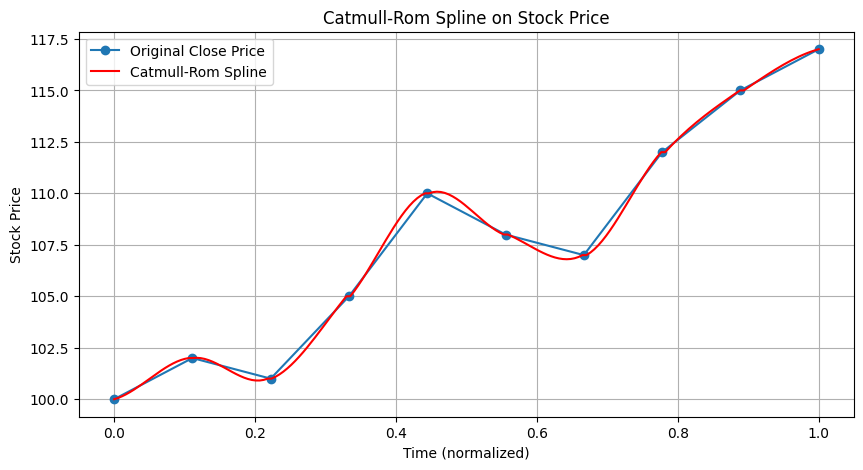

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sample time series data (replace this with your stock data)
# Format: DataFrame with 'Date' and 'Close' columns
data = {
    "Date": pd.date_range(start="2024-01-01", periods=10, freq='H'),
    "Close": [100, 102, 101, 105, 110, 108, 107, 112, 115, 117]
}
df = pd.DataFrame(data)

# Convert dates to numerical values for spline interpolation
x = np.linspace(0, 1, len(df))
y = np.array(df["Close"])

# Function to create Catmull-Rom Spline between 4 points
def catmull_rom_chain(P, n_points=10):
    def catmull_rom_one(p0, p1, p2, p3, n):
        t = np.linspace(0, 1, n)
        t = t.reshape(len(t), 1)
        a = 2 * p1
        b = p2 - p0
        c = 2*p0 - 5*p1 + 4*p2 - p3
        d = -p0 + 3*p1 - 3*p2 + p3
        return 0.5 * (a + (b * t) + (c * t**2) + (d * t**3))

    curve = []
    for i in range(len(P) - 3):
        segment = catmull_rom_one(P[i], P[i+1], P[i+2], P[i+3], n_points)
        curve.append(segment)
    return np.concatenate(curve)

# Pad with extra points on both ends to start and end cleanly
pad_y = np.concatenate(([y[0]], y, [y[-1]]))
points = np.array(pad_y)

# Generate smooth curve points
smooth_y = catmull_rom_chain(points, n_points=20)
smooth_x = np.linspace(0, 1, len(smooth_y))

# Plot the result
plt.figure(figsize=(10, 5))
plt.plot(x, y, 'o-', label="Original Close Price")
plt.plot(smooth_x, smooth_y, 'r-', label="Catmull-Rom Spline")
plt.xlabel("Time (normalized)")
plt.ylabel("Stock Price")
plt.title("Catmull-Rom Spline on Stock Price")
plt.legend()
plt.grid(True)
plt.show()


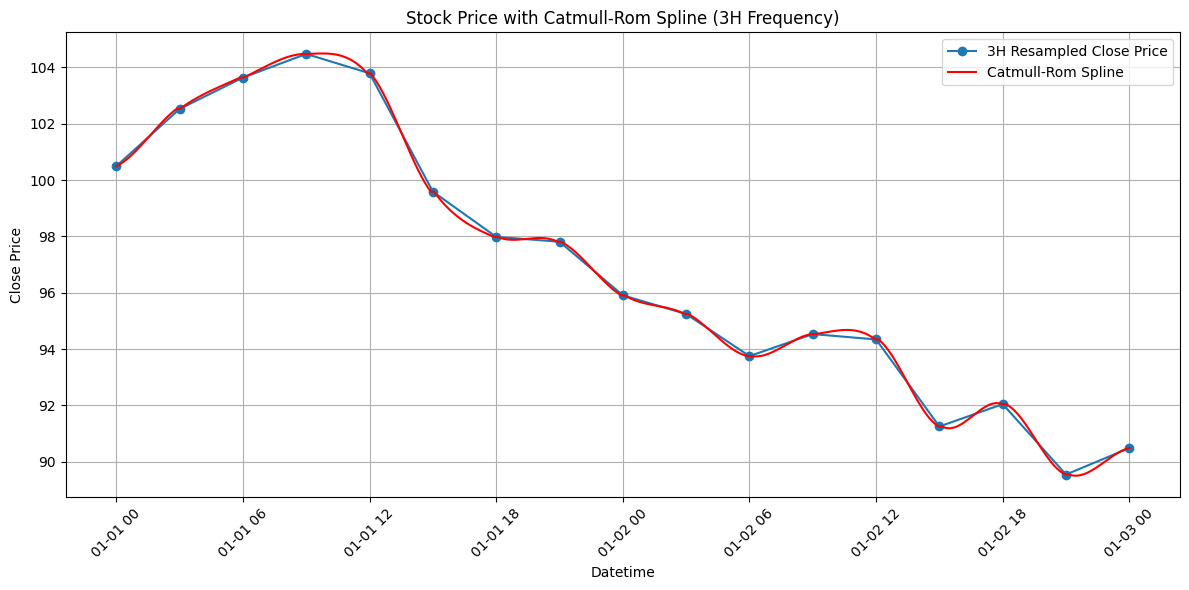

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sample intraday time series data — replace with your actual data
# For this demo, we generate hourly data over 2 days
date_rng = pd.date_range(start='2024-01-01', end='2024-01-03', freq='H')
np.random.seed(42)
price = np.cumsum(np.random.randn(len(date_rng))) + 100

df = pd.DataFrame({'Datetime': date_rng, 'Close': price})
df.set_index('Datetime', inplace=True)

# 👉 Resample to 3-hour frequency
df_3h = df.resample('3H').asfreq().interpolate()

# Get the x and y for the spline
x = np.linspace(0, 1, len(df_3h))
y = df_3h['Close'].values

# Pad the points to apply Catmull-Rom
pad_y = np.concatenate(([y[0]], y, [y[-1]]))
points = np.array(pad_y)

# Catmull-Rom Spline function
def catmull_rom_chain(P, n_points=10):
    def catmull_rom_one(p0, p1, p2, p3, n):
        t = np.linspace(0, 1, n).reshape(n, 1)
        a = 2 * p1
        b = p2 - p0
        c = 2*p0 - 5*p1 + 4*p2 - p3
        d = -p0 + 3*p1 - 3*p2 + p3
        return 0.5 * (a + b*t + c*t**2 + d*t**3)
    
    curve = []
    for i in range(len(P) - 3):
        segment = catmull_rom_one(P[i], P[i+1], P[i+2], P[i+3], n_points)
        curve.append(segment)
    return np.concatenate(curve)

# Apply Catmull-Rom spline
smooth_y = catmull_rom_chain(points, n_points=20)
smooth_x = np.linspace(df_3h.index[0].timestamp(), df_3h.index[-1].timestamp(), len(smooth_y))
smooth_x_datetime = pd.to_datetime(smooth_x, unit='s')

# Plot the result
plt.figure(figsize=(12, 6))
plt.plot(df_3h.index, y, 'o-', label='3H Resampled Close Price')
plt.plot(smooth_x_datetime, smooth_y, 'r-', label='Catmull-Rom Spline')
plt.xlabel("Datetime")
plt.ylabel("Close Price")
plt.title("Stock Price with Catmull-Rom Spline (3H Frequency)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


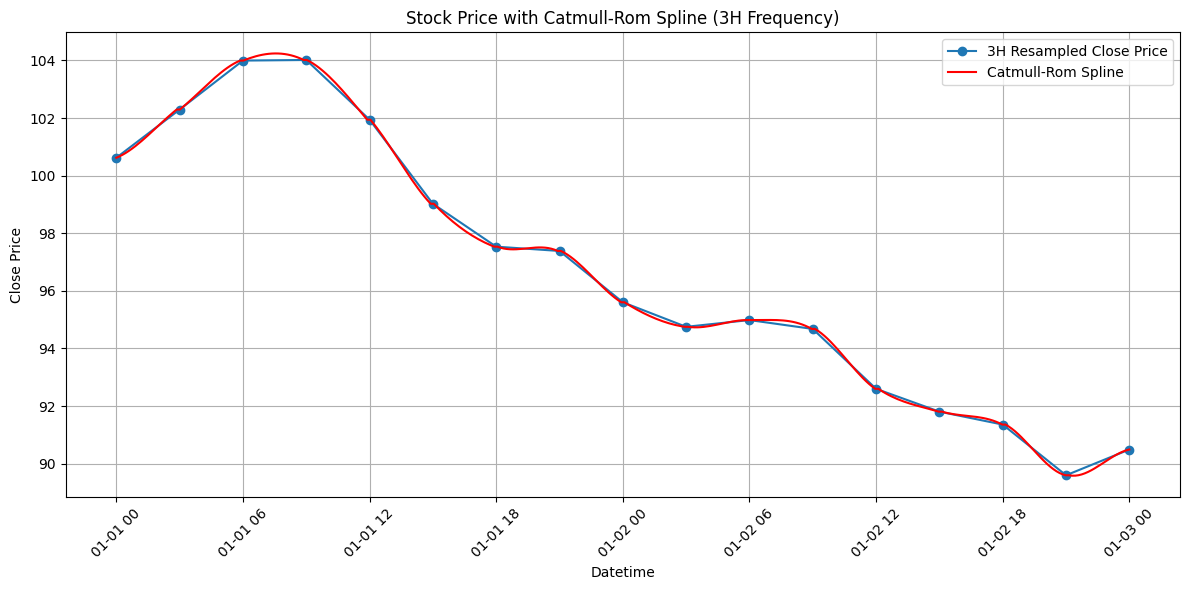

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sample intraday time series data — replace with your actual data
# For this demo, we generate hourly data over 2 days
date_rng = pd.date_range(start='2024-01-01', end='2024-01-03', freq='H')
np.random.seed(42)
price = np.cumsum(np.random.randn(len(date_rng))) + 100

df = pd.DataFrame({'Datetime': date_rng, 'Close': price})
df.set_index('Datetime', inplace=True)

# 👉 Resample to 3-hour frequency
df_3h = df.resample('3H').mean().interpolate()

# Get the x and y for the spline
x = np.linspace(0, 1, len(df_3h))
y = df_3h['Close'].values

# Pad the points to apply Catmull-Rom
pad_y = np.concatenate(([y[0]], y, [y[-1]]))
points = np.array(pad_y)

# Catmull-Rom Spline function
def catmull_rom_chain(P, n_points=10):
    def catmull_rom_one(p0, p1, p2, p3, n):
        t = np.linspace(0, 1, n).reshape(n, 1)
        a = 2 * p1
        b = p2 - p0
        c = 2*p0 - 5*p1 + 4*p2 - p3
        d = -p0 + 3*p1 - 3*p2 + p3
        return 0.5 * (a + b*t + c*t**2 + d*t**3)
    
    curve = []
    for i in range(len(P) - 3):
        segment = catmull_rom_one(P[i], P[i+1], P[i+2], P[i+3], n_points)
        curve.append(segment)
    return np.concatenate(curve)

# Apply Catmull-Rom spline
smooth_y = catmull_rom_chain(points, n_points=20)
smooth_x = np.linspace(df_3h.index[0].timestamp(), df_3h.index[-1].timestamp(), len(smooth_y))
smooth_x_datetime = pd.to_datetime(smooth_x, unit='s')

# Plot the result
plt.figure(figsize=(12, 6))
plt.plot(df_3h.index, y, 'o-', label='3H Resampled Close Price')
plt.plot(smooth_x_datetime, smooth_y, 'r-', label='Catmull-Rom Spline')
plt.xlabel("Datetime")
plt.ylabel("Close Price")
plt.title("Stock Price with Catmull-Rom Spline (3H Frequency)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


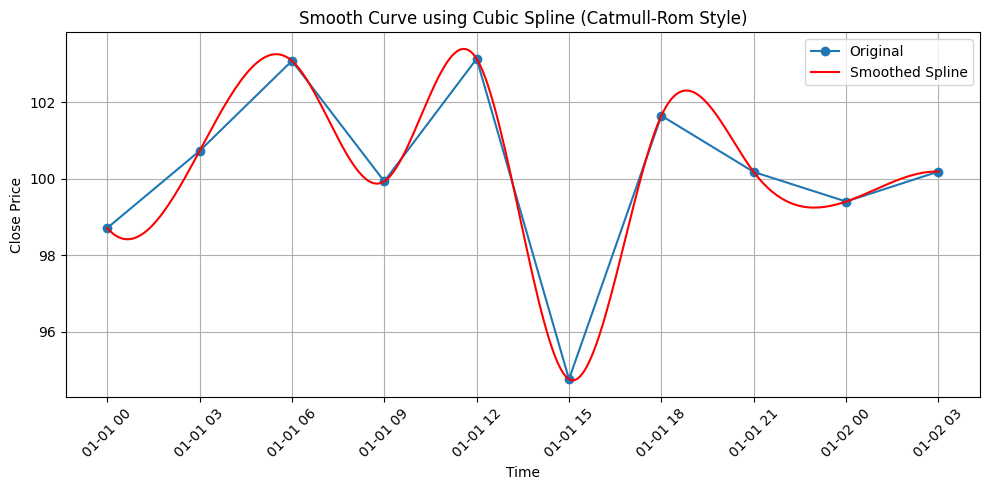

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import matplotlib.dates as mdates

# Sample time series data
date_rng = pd.date_range(start='2024-01-01', periods=10, freq='3H')
price = np.random.normal(loc=100, scale=2, size=len(date_rng))

df = pd.DataFrame({'Datetime': date_rng, 'Close': price})
df.set_index('Datetime', inplace=True)

# Use matplotlib dates for interpolation instead of big integers
x = mdates.date2num(df.index.to_pydatetime())  # convert datetime to float days
y = df['Close'].values

# Create smooth x-axis values
x_smooth = np.linspace(x.min(), x.max(), 300)
spline = make_interp_spline(x, y, k=3)
y_smooth = spline(x_smooth)

# Convert x_smooth back to datetime for plotting
x_smooth_dates = mdates.num2date(x_smooth)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(df.index, y, 'o-', label='Original')
plt.plot(x_smooth_dates, y_smooth, 'r-', label='Smoothed Spline')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.title('Smooth Curve using Cubic Spline (Catmull-Rom Style)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/var/folders/f7/m8hfzm0j30l8vf635dzs58lc0000gn/T/ipykernel_2402/3312922529.py:23: RuntimeWarning: divide by zero encountered in divide
  A1 = (t1 - t) / (t1 - t0) * p0 + (t - t0) / (t1 - t0) * p1
/var/folders/f7/m8hfzm0j30l8vf635dzs58lc0000gn/T/ipykernel_2402/3312922529.py:23: RuntimeWarning: invalid value encountered in divide
  A1 = (t1 - t) / (t1 - t0) * p0 + (t - t0) / (t1 - t0) * p1
/var/folders/f7/m8hfzm0j30l8vf635dzs58lc0000gn/T/ipykernel_2402/3312922529.py:23: RuntimeWarning: invalid value encountered in multiply
  A1 = (t1 - t) / (t1 - t0) * p0 + (t - t0) / (t1 - t0) * p1
/var/folders/f7/m8hfzm0j30l8vf635dzs58lc0000gn/T/ipykernel_2402/3312922529.py:23: RuntimeWarning: invalid value encountered in add
  A1 = (t1 - t) / (t1 - t0) * p0 + (t - t0) / (t1 - t0) * p1
/var/folders/f7/m8hfzm0j30l8vf635dzs58lc0000gn/T/ipykernel_2402/3312922529.py:25: RuntimeWarning: divide by zero encountered in divide
  A3 = (t3 - t) / (t3 - t2) * p2 + (t - t2) / (t3 - t2) * p3
/var/folders/f7/m8hfzm0j

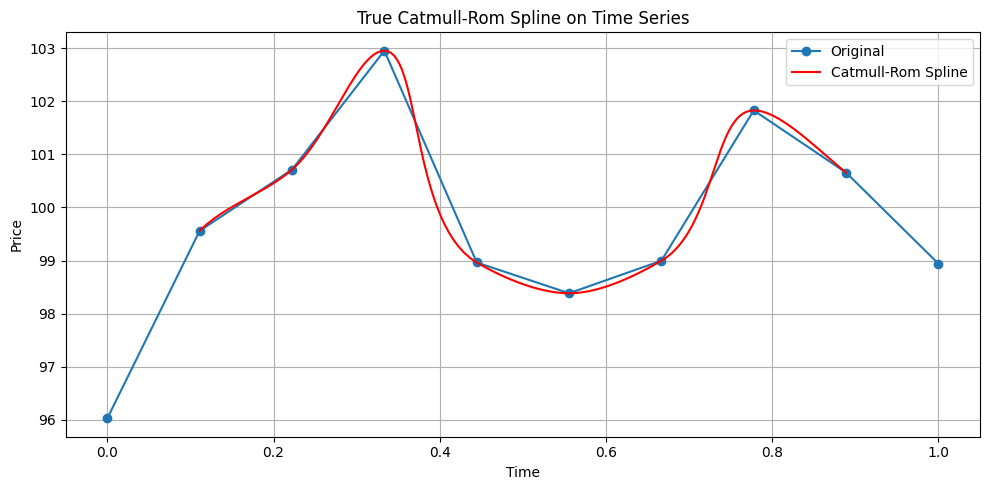

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def catmull_rom_spline(P, n_points=100):
    """Compute Catmull-Rom spline for a set of points"""
    alpha = 0.5  # Centripetal Catmull-Rom
    def tj(ti, pi, pj):
        return ((np.linalg.norm(pj - pi)) ** alpha) + ti

    curve = []
    for i in range(1, len(P) - 2):
        p0, p1, p2, p3 = P[i - 1], P[i], P[i + 1], P[i + 2]

        t0 = 0
        t1 = tj(t0, p0, p1)
        t2 = tj(t1, p1, p2)
        t3 = tj(t2, p2, p3)

        t = np.linspace(t1, t2, n_points)
        t = t[:, np.newaxis]

        A1 = (t1 - t) / (t1 - t0) * p0 + (t - t0) / (t1 - t0) * p1
        A2 = (t2 - t) / (t2 - t1) * p1 + (t - t1) / (t2 - t1) * p2
        A3 = (t3 - t) / (t3 - t2) * p2 + (t - t2) / (t3 - t2) * p3

        B1 = (t2 - t) / (t2 - t0) * A1 + (t - t0) / (t2 - t0) * A2
        B2 = (t3 - t) / (t3 - t1) * A2 + (t - t1) / (t3 - t1) * A3

        C = (t2 - t) / (t2 - t1) * B1 + (t - t1) / (t2 - t1) * B2
        curve.extend(C)
    return np.array(curve)

# ------------------------
# 💾 Example with stock-like time series
# ------------------------
# Fake stock time series
date_rng = pd.date_range(start='2024-01-01', periods=10, freq='3H')
prices = np.random.normal(loc=100, scale=2, size=len(date_rng))

# Convert to 2D points: [time, price]
# Normalize time to floats
time_numeric = np.linspace(0, 1, len(date_rng))
points = np.array([[t, p] for t, p in zip(time_numeric, prices)])

# Pad the points to allow full segment generation
points = np.vstack([points[0], points, points[-1]])

# Generate smooth curve
smooth_points = catmull_rom_spline(points, n_points=30)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(time_numeric, prices, 'o-', label='Original')
plt.plot(smooth_points[:, 0], smooth_points[:, 1], 'r-', label='Catmull-Rom Spline')
plt.title('True Catmull-Rom Spline on Time Series')
plt.xlabel('Time')
plt.ylabel('Price')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [23]:
fd=pd.DataFrame({
    'sedol':['a','b','c','d','e','f','g','h'],
    'region':['Af','Bh','Cg','Df','Af','Bh','Cg','Df'],
    'prices':[10,23,40,50,20,10,20,40]
})

In [24]:
x=fd.groupby('region').sum()

In [27]:
for vl in x.index:
    print(vl)

Af
Bh
Cg
Df


In [28]:
import pandas as pd

df = pd.DataFrame({
    "Stock": ["AAPL", "GOOG", "TSLA"],
    "Price": [150, 2800, 700]
})

styled = df.style.format({"Price": "${:.2f}"}).highlight_max(axis=0)
styled


,Stock,Price
0,AAPL,$150.00
1,GOOG,$2800.00
2,TSLA,$700.00


In [ ]:
import pandas as pd

# Sample DataFrame
df = pd.DataFrame({
    'Region': ['North', 'South', 'East', 'West'],
    'Sales': [200, -150, 300, -50],
    'Profit': [20, -10, 40, -5]
})

# Function to highlight negative rows
def highlight_negatives(row):
    return ['color: red' if isinstance(val,(int,float))and val < 0 else '' for val in row]

# Apply styling
styled = (
    df.style
    .apply(highlight_negatives, axis=1)  # Row-wise styling
    .set_properties(subset=['Region'], **{'font-weight': 'bold', 'color': 'blue'})  # Column-specific
    .set_table_styles([  # Table-level styling (headers, etc.)
        {'selector': 'th', 'props': [('background-color', '#f2f2f2'), ('border', '1px solid black')]},
        {'selector': 'td', 'props': [('border', '1px solid lightgray')]}
    ])
)

# Render to HTML
html_output = styled.to_html()

# Save to file (optional)
with open("styled_table.html", "w") as f:
    f.write(html_output)


In [33]:
import pandas as pd

df = pd.DataFrame({
    'Region': ['North', 'South', 'East'],
    'Sales': [200, -150, 300]
})

# Style the DataFrame and hide the index
styled = (
    df.style
    .map(lambda x: 'color: red' if isinstance(x, (int, float)) and x < 0 else '')
    .hide(axis='index')  # ✅ Removes index from display
)

# Render to HTML
html_output = styled.to_html()

# Save to file (optional)
with open("styled_table.html", "w") as f:
    f.write(html_output)

In [34]:
import time

# def timer(func):
#     def wrapper(*args, **kwargs):
#         start = time.time()
#         result = func(*args, **kwargs)
#         end = time.time()
#         print(f"{func.__name__} ran in {end - start:.4f} seconds")
#         return result
#     return wrapper


def timer(func):
    def wrapper(*args,**kwargs):
        start = time.time()
        result = func(*args,**kwargs)
        end = time.time()
        print(f"{func.__name__} ran in {end - start:.4f} seconds")
        return result
    return wrapper


In [35]:
@timer
def sums(x,y,z):
    return x+y+z

In [36]:
sums(3,45,6)

sums ran in 0.0000 seconds


54

In [37]:
@timer
def printmyname():
    print("hey man")

In [38]:
printmyname()

hey man
printmyname ran in 0.0000 seconds
